In [ ]:
import pandas as pd
df=pd.read_csv("earthquake_1995-2023.csv")
print("Rows and columns:",df.shape)
df.head()


Rows and columns: (1000, 19)


,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,16/08/2023 12:47,7,4,green,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,Vanuatu
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,19/07/2023 00:22,8,6,yellow,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,NaN
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,17/07/2023 03:05,7,5,green,0,899,us,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,16/07/2023 06:48,6,6,green,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,NaN
4,M 7.3 - Alaska Peninsula,7.3,16/07/2023 06:48,0,5,NaN,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,NaN


/tmp/ipykernel_867/2755465400.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries, x="count", y="country", palette="magma")


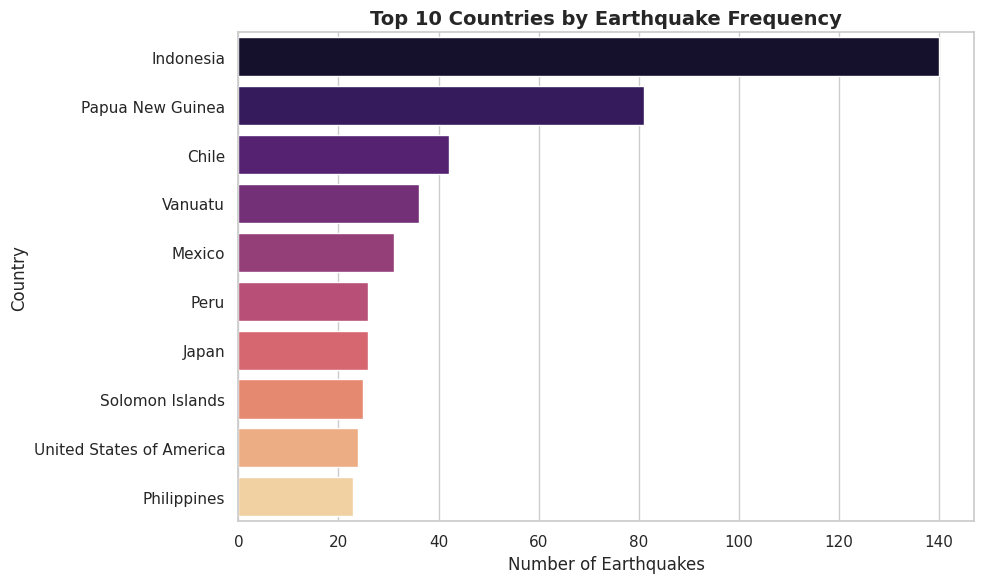

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get top 10 most frequent countries in the dataset
top_countries = df['country'].value_counts().head(10).reset_index()
top_countries.columns = ['country', 'count']

# Create horizontal bar plot for better label readability
plt.figure(figsize=(10, 6))
sns.barplot(data=top_countries, x="count", y="country", palette="magma")

plt.title("Top 10 Countries by Earthquake Frequency", fontsize=14, fontweight="bold")
plt.xlabel("Number of Earthquakes", fontsize=12)
plt.ylabel("Country", fontsize=12)

plt.tight_layout()
plt.show()

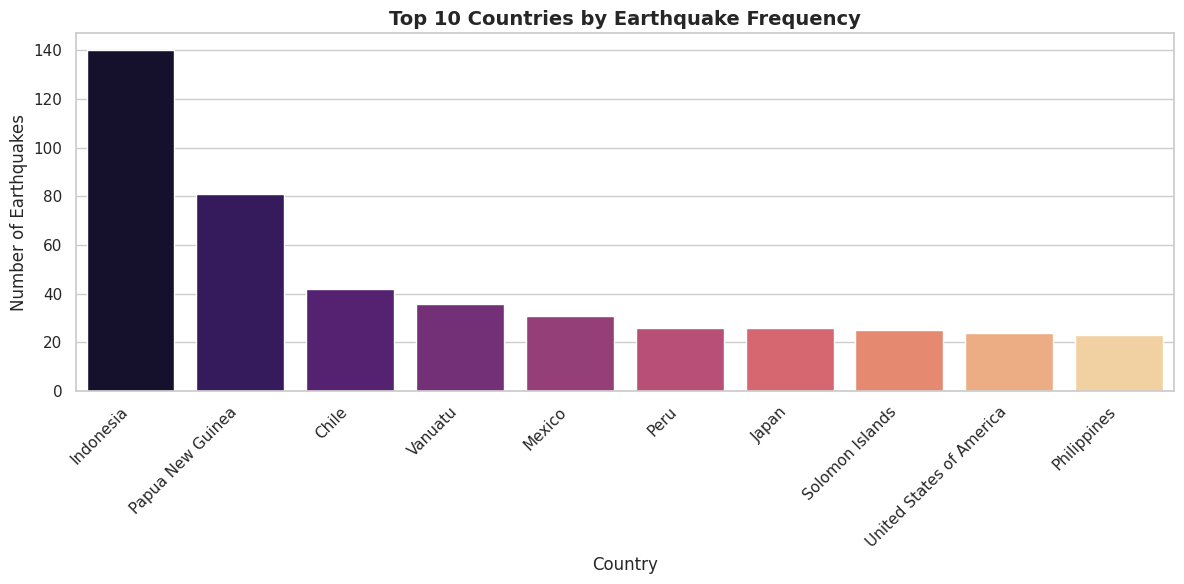

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get top 10 most frequent countries in the dataset
top_countries = df['country'].value_counts().head(10).reset_index()

# Correctly rename columns (use .columns, not .rows)
top_countries.columns = ['country', 'count']

# Create vertical bar plot (x = country, y = count)
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_countries,
    x="country",
    y="count",
    hue="country",
    palette="magma",
    legend=False
)

plt.title("Top 10 Countries by Earthquake Frequency", fontsize=14, fontweight="bold")
plt.xlabel("Country", fontsize=12)
plt.ylabel("Number of Earthquakes", fontsize=12)

# Rotate x-axis labels so country names don't overlap
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


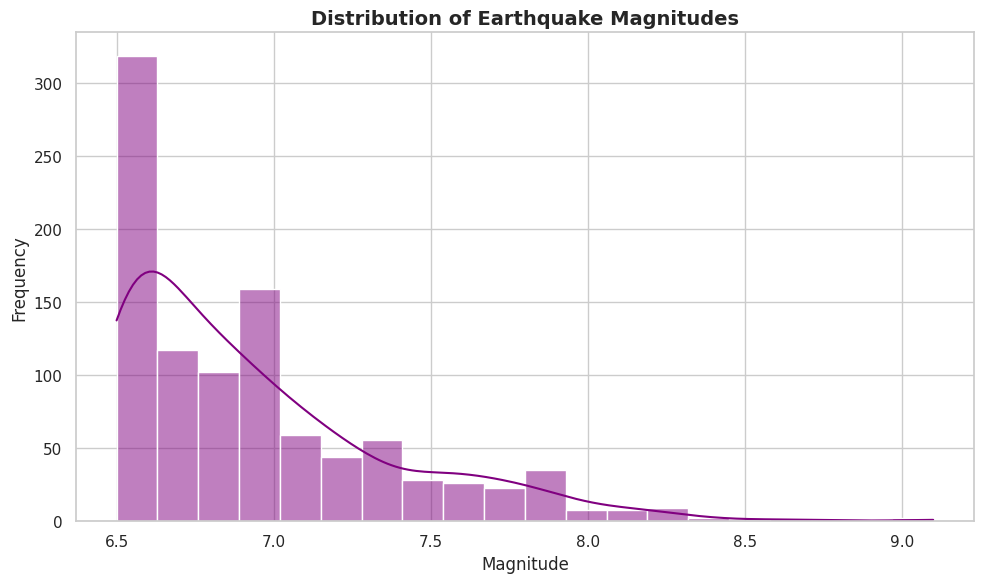

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size
plt.figure(figsize=(10, 6))

# Plot histogram with a smooth KDE (Kernel Density Estimate) curve
sns.histplot(data=df, x="magnitude", bins=20, kde=True, color="purple")

# Add title and axis labels
plt.title("Distribution of Earthquake Magnitudes", fontsize=14, fontweight="bold")
plt.xlabel("Magnitude", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# Adjust layout and display plot
plt.tight_layout()
plt.show()

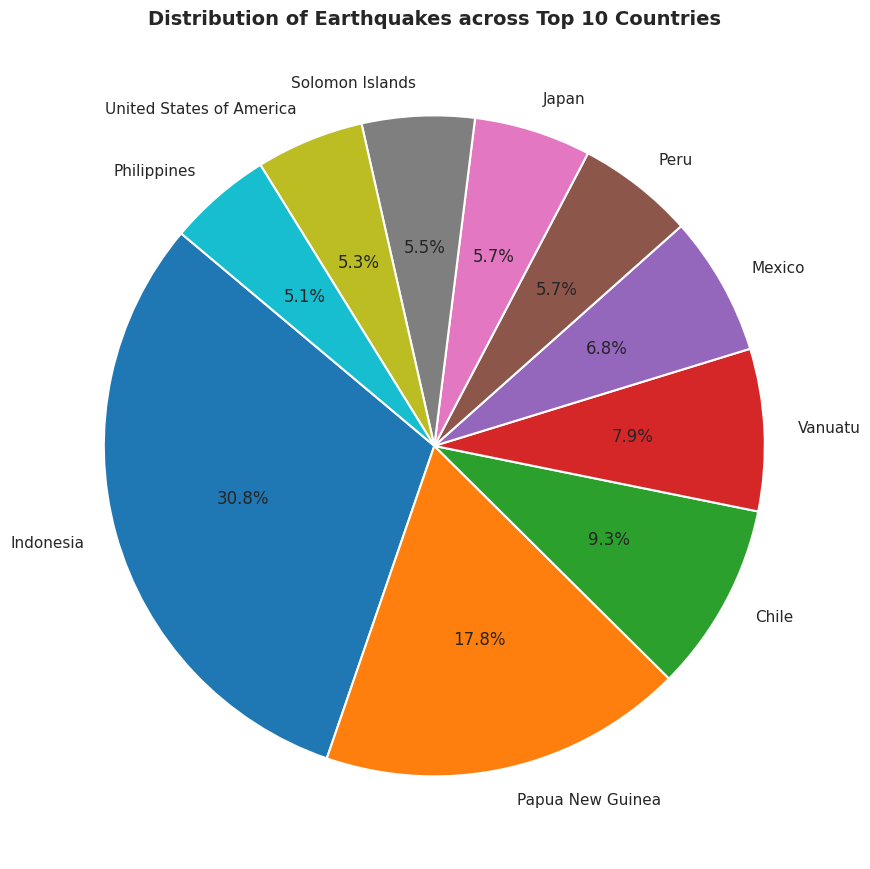

In [ ]:
import matplotlib.pyplot as plt

# Get the count of earthquakes for the top 10 most frequent countries
top_countries = df['country'].value_counts().head(10)

# Create pie chart
plt.figure(figsize=(9, 9))
plt.pie(
    top_countries,
    labels=top_countries.index,
    autopct='%1.1f%%',            # Display percentage on each slice
    startangle=140,
    colors=plt.cm.tab10.colors,   # Distinct 10-color palette
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

plt.title("Distribution of Earthquakes across Top 10 Countries", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

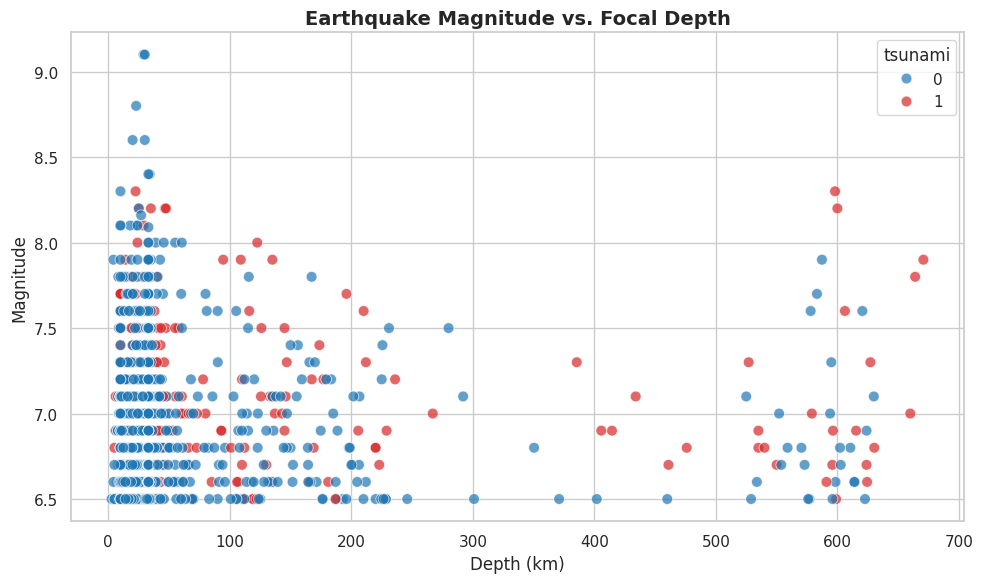

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Create scatter plot
sns.scatterplot(
    data=df,
    x="depth",
    y="magnitude",
    hue="tsunami",           # Colors points based on tsunami warning (0 or 1)
    palette={0: "#1f77b4", 1: "#d62728"},
    alpha=0.7,               # Adds transparency to see overlapping points
    s=60                     # Marker size
)

plt.title("Earthquake Magnitude vs. Focal Depth", fontsize=14, fontweight="bold")
plt.xlabel("Depth (km)", fontsize=12)
plt.ylabel("Magnitude", fontsize=12)

plt.tight_layout()
plt.show()

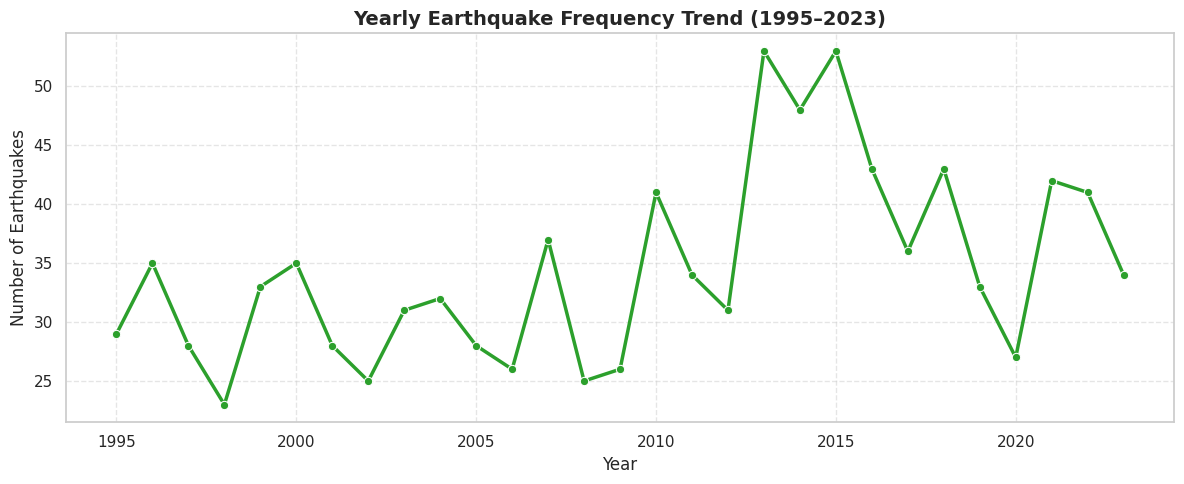

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert date_time to datetime object and extract year
df['year'] = pd.to_datetime(df['date_time'], format="%d/%m/%Y %H:%M", errors='coerce').dt.year

# Count earthquakes per year
yearly_counts = df.groupby('year').size().reset_index(name='count')

plt.figure(figsize=(12, 5))

# Create line plot
sns.lineplot(
    data=yearly_counts,
    x="year",
    y="count",
    marker="o",
    color="#2ca02c",
    linewidth=2.5
)

plt.title("Yearly Earthquake Frequency Trend (1995–2023)", fontsize=14, fontweight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Earthquakes", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()